# Análise exploratória do dataset político

O arquivo é `dataset_recogna_politica_balanceado.csv`. O alvo é `rotulo`: **0 falso** e **1 verdadeiro**.

As taxas (`erros_ortograficos` e as contagens gramaticais) já estão divididas pelo total de palavras. `quantidade_palavras`, `sentimento` e `prob_neutro` não entram no arquivo: o tamanho do texto, nesta análise, é contado direto da notícia.

O objetivo desta leitura é preparar o uso em machine learning: ver o que separa as classes de verdade e o que é só artefato da coleta, como site, época ou vocabulário de checagem.

In [50]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer

sns.set_theme(style="whitegrid")
df = pd.read_csv("dataset_recogna_politica_balanceado.csv")
df["data"] = pd.to_datetime(df["data"])
df["dominio"] = df["url"].fillna("sem url")
rotulo_nome = {0: "falso", 1: "verdadeiro"}

numericas = [
    "quantidade_pontuacao",
    "prob_negativo",
    "prob_positivo",
    "erros_ortograficos",
    "quantidade_adverbios",
    "quantidade_substantivos",
    "quantidade_adjetivos",
    "quantidade_verbos",
    "quantidade_substantivos_proprios",
    "quantidade_pronomes",
    "rotulo",
]

df.shape, df["rotulo"].map(rotulo_nome).value_counts()

((8770, 18),
 rotulo
 verdadeiro    4385
 falso         4385
 Name: count, dtype: int64)

## Mapa de correlação

O heatmap usa as variáveis numéricas e o alvo. Correlação alta com `rotulo` não prova que a variável detecta notícia falsa: pode ser um atalho da coleta. Correlação alta entre duas features, sem o alvo, indica redundância e risco de overfitting.

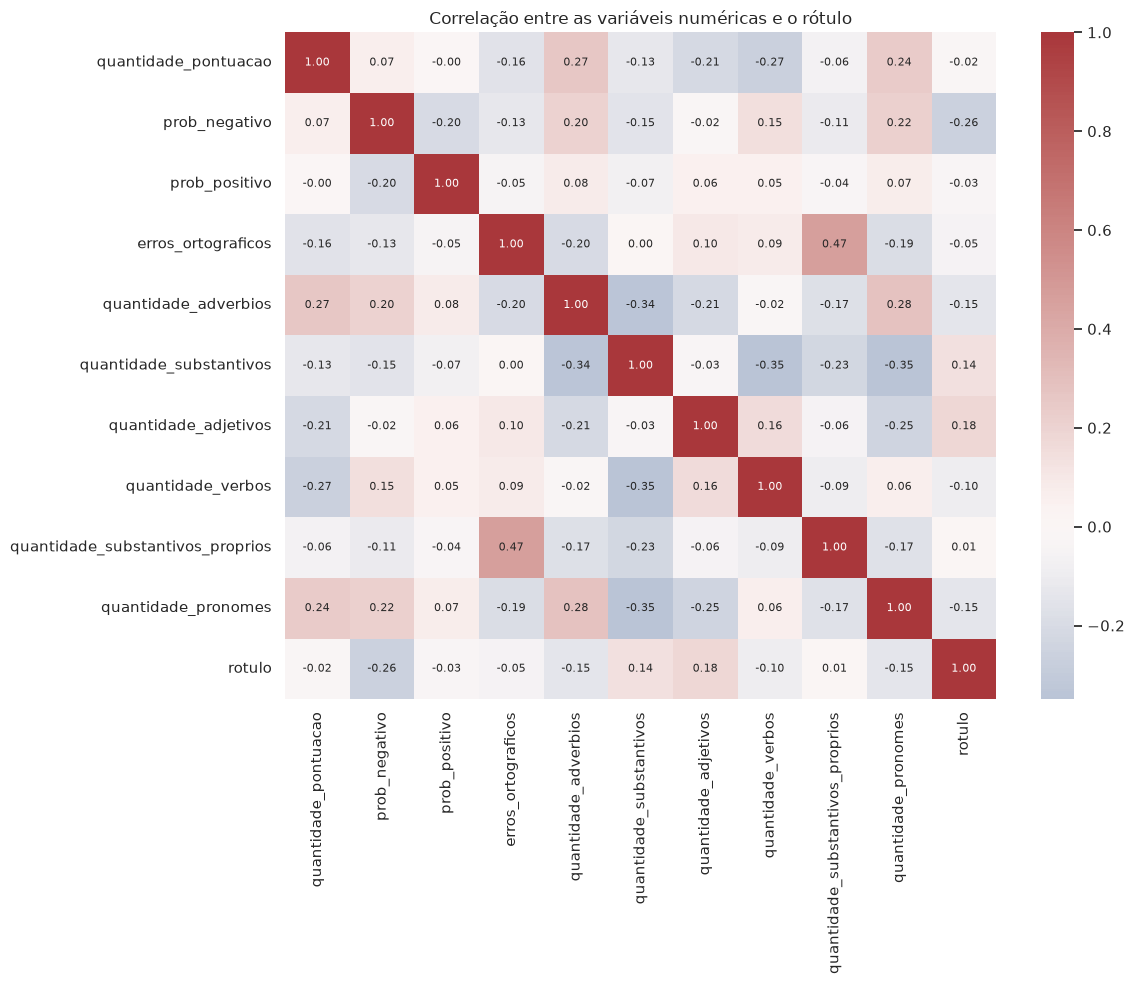

prob_negativo                      -0.256945
quantidade_adjetivos                0.179085
quantidade_pronomes                -0.148209
quantidade_adverbios               -0.145410
quantidade_substantivos             0.135953
quantidade_verbos                  -0.098504
erros_ortograficos                 -0.054503
prob_positivo                      -0.032074
quantidade_pontuacao               -0.020834
quantidade_substantivos_proprios    0.012800
Name: correlação com rotulo, dtype: float64

In [51]:
correlacao = df[numericas].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    correlacao,
    cmap="vlag",
    center=0,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 8},
    ax=ax,
)
ax.set_title("Correlação entre as variáveis numéricas e o rótulo")
plt.tight_layout()
plt.show()

com_alvo = correlacao["rotulo"].drop("rotulo").sort_values(key=abs, ascending=False)
com_alvo.rename("correlação com rotulo")

## Tamanho do texto por classe

O tamanho é o número de palavras da notícia, contado aqui só para o gráfico. Os intervalos mostram se uma classe se concentra em textos curtos e a outra em textos longos. Se isso acontecer, um modelo pode aprender o tamanho em vez do conteúdo.

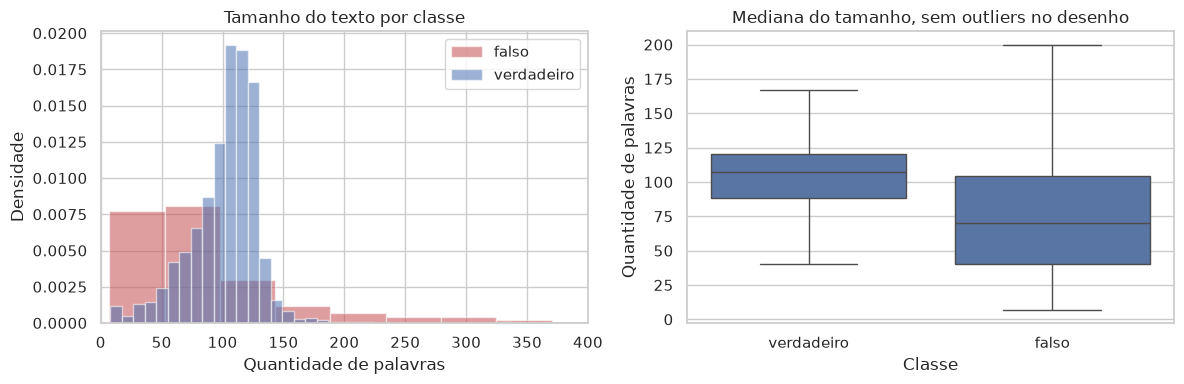

rotulo,falso,verdadeiro
noticia,,
1-50,0.332,0.053
51-100,0.400,0.338
101-150,0.128,0.592
151-200,0.052,0.014
201-300,0.045,0.003
301-500,0.031,0.001
501+,0.012,0.000


In [52]:
tamanho = df["noticia"].astype(str).str.split().str.len()

fig, eixos = plt.subplots(1, 2, figsize=(12, 4))
for classe, cor in [(0, "#c44e52"), (1, "#4c72b0")]:
    parte = tamanho.loc[df["rotulo"].eq(classe)]
    eixos[0].hist(parte, bins=40, alpha=0.55, color=cor, label=rotulo_nome[classe], density=True)
eixos[0].set_xlim(0, 400)
eixos[0].set_xlabel("Quantidade de palavras")
eixos[0].set_ylabel("Densidade")
eixos[0].set_title("Tamanho do texto por classe")
eixos[0].legend()

sns.boxplot(
    data=df.assign(tamanho=tamanho),
    x=df["rotulo"].map(rotulo_nome),
    y="tamanho",
    ax=eixos[1],
    showfliers=False,
)
eixos[1].set_xlabel("Classe")
eixos[1].set_ylabel("Quantidade de palavras")
eixos[1].set_title("Mediana do tamanho, sem outliers no desenho")
plt.tight_layout()
plt.show()

intervalos = [0, 50, 100, 150, 200, 300, 500, tamanho.max() + 1]
nomes_intervalos = ["1-50", "51-100", "101-150", "151-200", "201-300", "301-500", "501+"]
faixa = pd.cut(tamanho, bins=intervalos, labels=nomes_intervalos, include_lowest=True)
proporcao_faixa = pd.crosstab(faixa, df["rotulo"].map(rotulo_nome), normalize="columns").round(3)
proporcao_faixa

## Palavras e n-gramas por classe

A frequência bruta mostra o assunto do corpus. A diferença entre classes mostra termos que um modelo pode memorizar: nome de veículo, palavra de checagem ou fórmula de boato. A taxa abaixo é a fração de textos da classe em que o termo aparece.

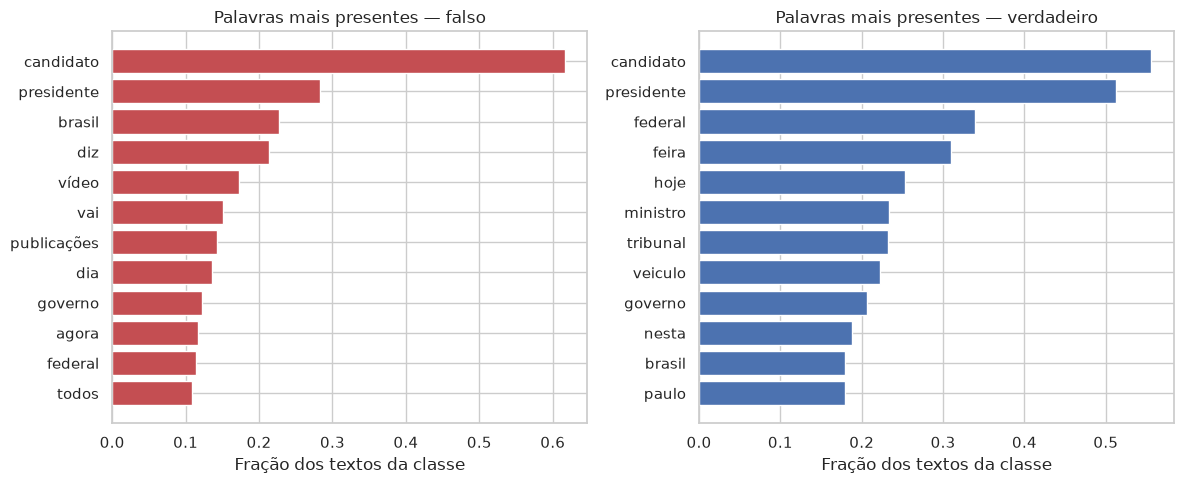

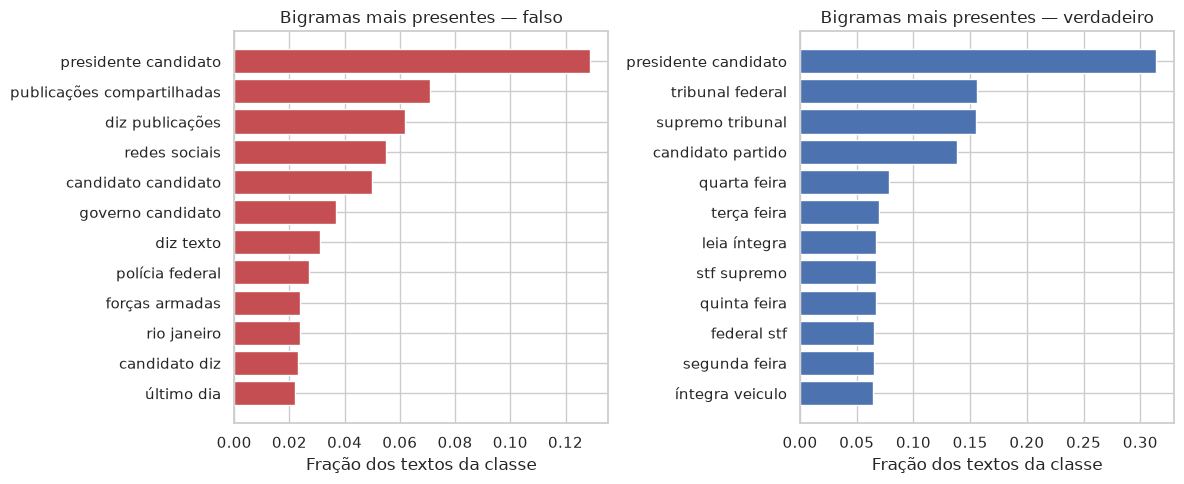

(               termo  taxa no falso  taxa no verdadeiro  diferença
 789              diz          0.213               0.041      0.173
 1949     publicações          0.143               0.004      0.139
 2501           vídeo          0.172               0.047      0.126
 1828             pra          0.097               0.006      0.091
 487   compartilhadas          0.088               0.000      0.087
 1827            povo          0.087               0.011      0.075
 2412             vai          0.151               0.075      0.075
 431          circula          0.070               0.001      0.069
 67             agora          0.117               0.048      0.069
 2330           todos          0.109               0.042      0.068
 555         conteúdo          0.080               0.017      0.062
 350        candidato          0.616               0.556      0.060,
            termo  taxa no falso  taxa no verdadeiro  diferença
 1008       feira          0.030               0.31

In [53]:
paradas = stopwords.words("portuguese")
padrao = r"(?u)\b[a-záàâãéêíóôõúüç]{3,}\b"


def frequencia(ngramas, min_df):
    vetor = CountVectorizer(
        stop_words=paradas,
        token_pattern=padrao,
        ngram_range=(ngramas, ngramas),
        min_df=min_df,
        binary=True,
    )
    matriz = vetor.fit_transform(df["noticia"].astype(str))
    termos = np.array(vetor.get_feature_names_out())
    return matriz, termos


def ranking(matriz, termos, classe, n=12):
    linhas = df["rotulo"].eq(classe).to_numpy()
    taxa = np.asarray(matriz[linhas].mean(axis=0)).ravel()
    ordem = taxa.argsort()[::-1][:n]
    return pd.DataFrame({"termo": termos[ordem], "taxa na classe": taxa[ordem].round(3)})


unigramas, termos_uni = frequencia(1, 30)
bigramas, termos_bi = frequencia(2, 15)

fig, eixos = plt.subplots(1, 2, figsize=(12, 5))
for eixo, classe, cor in zip(eixos, [0, 1], ["#c44e52", "#4c72b0"]):
    topo = ranking(unigramas, termos_uni, classe)
    eixo.barh(topo["termo"].tolist()[::-1], topo["taxa na classe"].tolist()[::-1], color=cor)
    eixo.set_title(f"Palavras mais presentes — {rotulo_nome[classe]}")
    eixo.set_xlabel("Fração dos textos da classe")
plt.tight_layout()
plt.show()

fig, eixos = plt.subplots(1, 2, figsize=(12, 5))
for eixo, classe, cor in zip(eixos, [0, 1], ["#c44e52", "#4c72b0"]):
    topo = ranking(bigramas, termos_bi, classe)
    eixo.barh(topo["termo"].tolist()[::-1], topo["taxa na classe"].tolist()[::-1], color=cor)
    eixo.set_title(f"Bigramas mais presentes — {rotulo_nome[classe]}")
    eixo.set_xlabel("Fração dos textos da classe")
plt.tight_layout()
plt.show()

falso = df["rotulo"].eq(0).to_numpy()
verdadeiro = df["rotulo"].eq(1).to_numpy()
taxa_falso = np.asarray(unigramas[falso].mean(axis=0)).ravel()
taxa_verdadeiro = np.asarray(unigramas[verdadeiro].mean(axis=0)).ravel()
contraste = pd.DataFrame(
    {
        "termo": termos_uni,
        "taxa no falso": taxa_falso,
        "taxa no verdadeiro": taxa_verdadeiro,
        "diferença": taxa_falso - taxa_verdadeiro,
    }
)
mais_no_falso = contraste.nlargest(12, "diferença").round(3)
mais_no_verdadeiro = contraste.nsmallest(12, "diferença").round(3)
mais_no_falso, mais_no_verdadeiro

## Distribuição temporal por classe

Se uma classe ocupa um período e a outra ocupa outro, o modelo pode aprender o ano em vez da notícia. O gráfico de cima é a contagem mensal. O de baixo é a fração de textos falsos em cada ano.

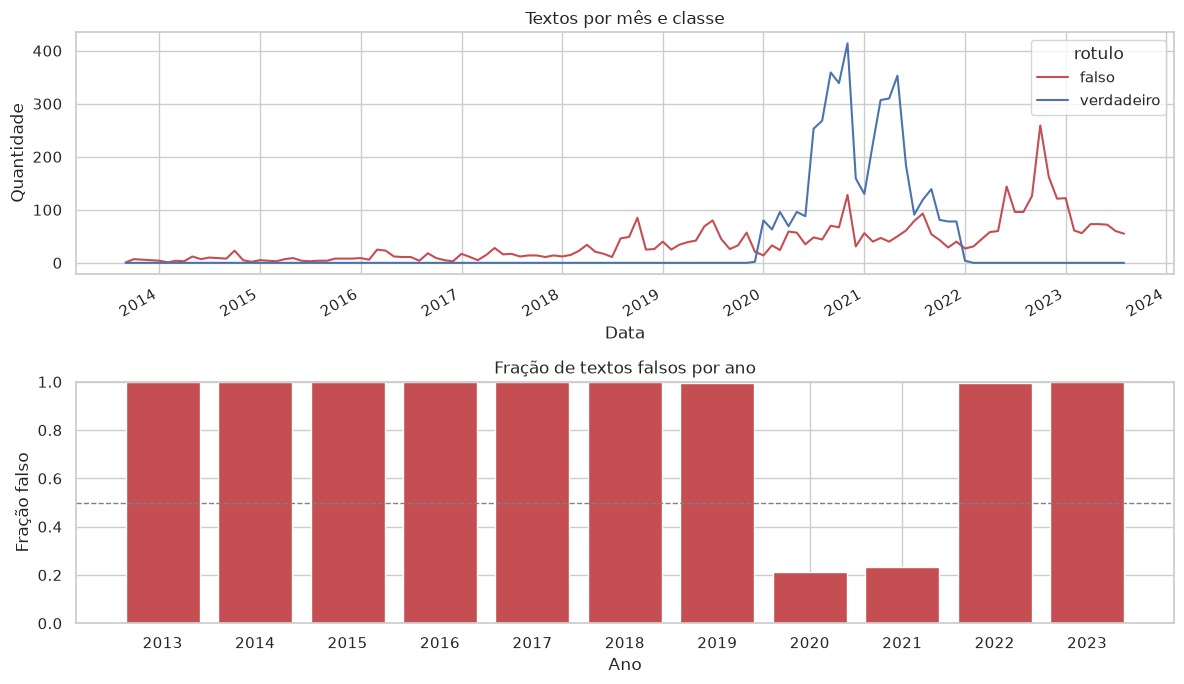

,textos,falsos,fração falso
data,,,
2013,8,8,1.000
2014,88,88,1.000
2015,67,67,1.000
2016,136,136,1.000
2017,174,174,1.000
2018,363,363,1.000
2019,513,511,0.996
2020,2894,610,0.211
2021,2727,632,0.232


In [54]:
mensal = (
    df.groupby([df["data"].dt.to_period("M"), "rotulo"])
    .size()
    .unstack(fill_value=0)
    .rename(columns=rotulo_nome)
)
mensal.index = mensal.index.to_timestamp()

anual = df.groupby(df["data"].dt.year)["rotulo"].agg(textos="size", falsos=lambda s: (s == 0).sum())
anual["fração falso"] = anual["falsos"] / anual["textos"]

fig, eixos = plt.subplots(2, 1, figsize=(12, 7))
mensal.plot(ax=eixos[0], color=["#c44e52", "#4c72b0"])
eixos[0].set_title("Textos por mês e classe")
eixos[0].set_xlabel("Data")
eixos[0].set_ylabel("Quantidade")
eixos[1].bar(anual.index.astype(str), anual["fração falso"], color="#c44e52")
eixos[1].axhline(0.5, color="gray", linestyle="--", linewidth=1)
eixos[1].set_ylim(0, 1)
eixos[1].set_title("Fração de textos falsos por ano")
eixos[1].set_xlabel("Ano")
eixos[1].set_ylabel("Fração falso")
plt.tight_layout()
plt.show()

anual.round(3)

## Anomalias, duplicatas e balanceamento

Nulos, textos repetidos e classes desiguais mudam a leitura da acurácia. Outlier aqui é o critério do intervalo interquartil: valor acima de Q3 + 1,5 IQR ou abaixo de Q1 − 1,5 IQR.

In [55]:
nulos = df.isna().sum()
nulos = nulos[nulos > 0]

repetidos_noticia = int(df["noticia"].duplicated().sum())
repetidos_titulo = int(df["titulo"].duplicated().sum())
titulos_em_conflito = int(
    df.dropna(subset=["titulo"]).groupby("titulo")["rotulo"].nunique().gt(1).sum()
)

def outliers(serie):
    q1, q3 = serie.quantile(0.25), serie.quantile(0.75)
    limite = 1.5 * (q3 - q1)
    return int(((serie < q1 - limite) | (serie > q3 + limite)).sum())

tabela_outliers = pd.Series(
    {coluna: outliers(df[coluna]) for coluna in numericas if coluna != "rotulo"},
    name="outliers",
).sort_values(ascending=False)

resumo_anomalias = pd.Series(
    {
        "linhas": len(df),
        "falsos": int(df["rotulo"].eq(0).sum()),
        "verdadeiros": int(df["rotulo"].eq(1).sum()),
        "notícias repetidas": repetidos_noticia,
        "títulos repetidos": repetidos_titulo,
        "títulos com os dois rótulos": titulos_em_conflito,
    }
)
resumo_anomalias, nulos, tabela_outliers

(linhas                         8770
 falsos                         4385
 verdadeiros                    4385
 notícias repetidas                0
 títulos repetidos                84
 títulos com os dois rótulos       1
 dtype: int64,
 titulo       2
 url       2143
 dtype: int64,
 prob_positivo                       742
 prob_negativo                       449
 quantidade_adjetivos                373
 erros_ortograficos                  338
 quantidade_substantivos_proprios    302
 quantidade_verbos                   302
 quantidade_substantivos             255
 quantidade_pronomes                 240
 quantidade_pontuacao                237
 quantidade_adverbios                207
 Name: outliers, dtype: int64)

## Diagnóstico de vazamento e falso aprendizado

Três artefatos costumam inflar a acurácia neste tipo de base: o domínio da URL, o calendário da coleta e palavras que só existem no texto de uma das classes. `prob_negativo` e `prob_positivo` vêm do mesmo modelo de sentimento, então não são sinais independentes.

In [56]:
pares = []
colunas = list(correlacao.columns)
for i, esquerda in enumerate(colunas):
    for direita in colunas[i + 1 :]:
        valor = correlacao.loc[esquerda, direita]
        if abs(valor) >= 0.7:
            pares.append((esquerda, direita, round(valor, 3)))
pares_redundantes = pd.DataFrame(pares, columns=["variável A", "variável B", "correlação"])

pureza = df.groupby("dominio")["rotulo"].nunique()
dominios_puros = pureza[pureza.eq(1)].index
linhas_puras = df["dominio"].isin(dominios_puros)
composicao = pd.crosstab(df["dominio"], df["rotulo"].map(rotulo_nome))
composicao["pureza"] = composicao.max(axis=1) / composicao.sum(axis=1)

print(f"Linhas em domínio de uma classe só: {linhas_puras.mean():.1%}")
print("Correlação mais forte com o rótulo:")
print(com_alvo.head(5).round(3).to_string())
print("Pares com correlação absoluta de pelo menos 0,7:")
print(pares_redundantes.to_string(index=False) if len(pares_redundantes) else "nenhum")

composicao.sort_values("pureza", ascending=False).round(3)

Linhas em domínio de uma classe só: 75.4%
Correlação mais forte com o rótulo:
prob_negativo             -0.257
quantidade_adjetivos       0.179
quantidade_pronomes       -0.148
quantidade_adverbios      -0.145
quantidade_substantivos    0.136
Pares com correlação absoluta de pelo menos 0,7:
nenhum


rotulo,falso,verdadeiro,pureza
dominio,,,
boatos.org,2649,0,1.000
checamos.afp.com,1004,0,1.000
e-farsas.com,210,0,1.000
economia.uol.com.br,0,102,1.000
educacao.uol.com.br,0,11,1.000
entretenimento.uol.com.br,0,1,1.000
sem url,0,2143,1.000
projetocomprova.com.br,472,0,1.000
tvefamosos.uol.com.br,0,3,1.000
